In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from google.colab import files
files.upload()

Saving order_items_clean.csv to order_items_clean.csv
Saving orders_clean.csv to orders_clean.csv
Saving products_clean.csv to products_clean.csv
Saving reviews_clean.csv to reviews_clean.csv
Saving customers_clean.csv to customers_clean.csv


{'order_items_clean.csv': b'item_id,order_id,product_id,quantity,unit_price_idr,subtotal_idr,calculated_subtotal\nITM000001,ORD000001,PRD070,1,349000,349000,349000\nITM000002,ORD000001,PRD001,2,599000,1198000,1198000\nITM000003,ORD000001,PRD148,1,449000,449000,449000\nITM000004,ORD000002,PRD086,1,329000,329000,329000\nITM000005,ORD000002,PRD258,1,129000,129000,129000\nITM000006,ORD000002,PRD256,1,49000,49000,49000\nITM000007,ORD000003,PRD076,1,199000,199000,199000\nITM000008,ORD000004,PRD205,1,119000,119000,119000\nITM000009,ORD000005,PRD239,2,179000,358000,358000\nITM000010,ORD000006,PRD170,1,349000,349000,349000\nITM000011,ORD000007,PRD013,1,149000,149000,149000\nITM000012,ORD000007,PRD230,2,129000,258000,258000\nITM000013,ORD000008,PRD281,1,149000,149000,149000\nITM000014,ORD000008,PRD290,3,279000,837000,837000\nITM000015,ORD000009,PRD202,1,249000,249000,249000\nITM000016,ORD000010,PRD034,1,279000,279000,279000\nITM000017,ORD000011,PRD191,3,49000,147000,147000\nITM000018,ORD000011,P

In [8]:
#Load all cleaned files
customers = pd.read_csv(
    "/content/customers_clean.csv"
)
products = pd.read_csv(
    "/content/products_clean.csv"
)
orders = pd.read_csv("/content/orders_clean.csv")
order_items = pd.read_csv(
    "/content/order_items_clean.csv"
)
reviews = pd.read_csv(
    "/content/reviews_clean.csv"
)

In [9]:
#Convert the dates again because CSV does not preserve Pandas datetime type:
orders["order_date"] = pd.to_datetime(
    orders["order_date"]
)

customers["registration_date"] = pd.to_datetime(
    customers["registration_date"]
)

reviews["review_date"] = pd.to_datetime(
    reviews["review_date"]
)

In [10]:
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Reviews:", reviews.shape)

Customers: (800, 9)
Products: (300, 9)
Orders: (3000, 20)
Order Items: (4986, 7)
Reviews: (1500, 8)


In [11]:
orders.head() #This is a quick confirmation that Day 1 output is working properly.

,order_id,customer_id,order_date,total_amount_idr,shipping_city,shipping_province,shipping_cost_idr,payment_method,order_status,promo_code,discount_amount_idr,courier,year,month,month_num,year_month,is_cancelled,is_returned,is_delivered,used_discount
0,ORD000001,CUST0474,2023-03-23,1951591,Banjarmasin,Kalimantan Selatan,32066,Transfer Bank,shipped,WEEKEND25,44409.0,JNE,2023,March,3,2023-03,0,0,0,1
1,ORD000002,CUST0478,2025-02-26,507000,Palembang,Sumatera Selatan,33769,Kartu Kredit,delivered,No Promo,0.0,JNE,2025,February,2,2025-02,0,0,1,0
2,ORD000003,CUST0306,2022-07-13,199000,Tangerang,Banten,12060,Transfer Bank,delivered,No Promo,0.0,SiCepat,2022,July,7,2022-07,0,0,1,0
3,ORD000004,CUST0777,2024-11-26,119000,Medan,Sumatera Utara,29005,Transfer Bank,cancelled,No Promo,0.0,Anteraja,2024,November,11,2024-11,1,0,0,0
4,ORD000005,CUST0210,2023-07-31,358000,Bandung,Jawa Barat,11192,Kartu Kredit,cancelled,No Promo,0.0,JNE,2023,July,7,2023-07,1,0,0,0


In [12]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   order_id             3000 non-null   object        
 1   customer_id          3000 non-null   object        
 2   order_date           3000 non-null   datetime64[ns]
 3   total_amount_idr     3000 non-null   int64         
 4   shipping_city        3000 non-null   object        
 5   shipping_province    3000 non-null   object        
 6   shipping_cost_idr    3000 non-null   int64         
 7   payment_method       3000 non-null   object        
 8   order_status         3000 non-null   object        
 9   promo_code           3000 non-null   object        
 10  discount_amount_idr  3000 non-null   float64       
 11  courier              3000 non-null   object        
 12  year                 3000 non-null   int64         
 13  month                3000 non-nul

In [14]:
'''First understand order statuses
This is important before calculating revenue.'''
orders["order_status"].value_counts()

,count
order_status,
delivered,1776
shipped,445
cancelled,328
processing,300
returned,151


In [16]:
# 1. Gross Order Value = value of all orders
gross_order_value = orders["total_amount_idr"].sum()

print("Gross Order Value:", gross_order_value)

Gross Order Value: 1494503946


In [17]:
'''Value from successfully delivered orders:
Delivered Revenue'''
delivered_orders = orders[
    orders["order_status"] == "delivered"
]

delivered_revenue = (
    delivered_orders["total_amount_idr"].sum()
)

In [19]:
print("Delivered Orders:", len(delivered_orders))
print(delivered_revenue)

Delivered Orders: 1776
877752049


In [22]:
'''KPI 1 — Total Revenue
KPI means Key Performance Indicator.
A KPI is an important number used to measure business performance.
Total value generated from successfully delivered orders.'''
total_revenue = delivered_orders[
    "total_amount_idr"
].sum()
print(total_revenue)

877752049


In [23]:
total_orders = orders["order_id"].nunique()
total_orders

3000

In [24]:
len(orders) #because order_id represents your actual unique orders.

3000

In [26]:
'''KPI 3 — Delivered Orders
KPI 3 — Delivered Orders'''
delivered_order_count = (
    orders.loc[
        orders["order_status"] == "delivered",
        "order_id"
    ]
    .nunique()
)

delivered_order_count

1776

In [27]:
'''KPI 4 — Total Customers
Number of unique customers who placed at least one order.'''
total_customers = (
    orders["customer_id"].nunique()
)
total_customers

787

In [28]:
customers["customer_id"].nunique()
#800 → total registered customers in the customers table.

800

In [29]:
orders["customer_id"].nunique()
#787 → customers who actually placed at least one order.

787

In [30]:
'''800 → total registered customers in the customers table.
AOV = Revenue / Number of Delivered Orders
Revenue = Rp 100,000,000 , Delivered Orders = 1,000 , AOV = Rp 100,000'''
average_order_value = total_revenue / delivered_order_count
print(average_order_value)

494229.7573198198


In [34]:
'''KPI 6 — Total Units Sold
orrect. Use order_items because units sold means product quantity, not number of orders.
First identify delivered order IDs:'''
delivered_ids = set(
    delivered_orders["order_id"]
)
print(len(delivered_ids))

1776


In [36]:
#Filter items belonging to delivered orders:
delivered_items = order_items[
    order_items["order_id"].isin(delivered_ids)
]
print(len(delivered_items))

2947


In [39]:
'''orders tells us about orders.
order_items tells us about individual products and quantities.'''
total_units_sold = (
    delivered_items["quantity"].sum()
)
print(total_units_sold)

3783


In [42]:
'''It tells you how many products are purchased on average in one delivered order.
round() is used to make the number easier to read., Keep 2 numbers after the decimal point.'''
avg_items_per_order = (
    total_units_sold /
    delivered_order_count
)

print(round(avg_items_per_order, 2))

2.13


In [43]:
'''this calculates the total discount amount from all orders.'''
total_discount = orders["discount_amount_idr"].sum()
print(total_discount)

37276054.0


In [46]:
'''It calculates the percentage of orders that were cancelled.
round() means make a decimal number shorter and cleaner.'''
cancellation_rate = (
    orders["is_cancelled"].mean() * 100
)

print(round(cancellation_rate, 3))

10.933


In [47]:
'''It calculates the percentage of orders that were returned.'''
return_rate = (
    orders["is_returned"].mean() * 100
)
round(return_rate, 2)

np.float64(5.03)

In [48]:
'''It calculates the average customer rating.
round() means make a decimal number shorter and cleaner.'''
average_rating = reviews["rating"].mean()
round(average_rating, 2)

np.float64(4.02)

In [49]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Orders",
        "Delivered Orders",
        "Total Customers",
        "Average Order Value",
        "Total Units Sold",
        "Average Items per Order",
        "Total Discount",
        "Cancellation Rate",
        "Return Rate",
        "Average Rating"
    ],
    "Value": [
        total_revenue,
        total_orders,
        delivered_order_count,
        total_customers,
        average_order_value,
        total_units_sold,
        avg_items_per_order,
        total_discount,
        cancellation_rate,
        return_rate,
        average_rating
    ]
})

kpi_summary
'''These KPIs will later become important parts of your Tableau dashboard.'''

,KPI,Value
0,Total Revenue,8.777520e+08
1,Total Orders,3.000000e+03
2,Delivered Orders,1.776000e+03
3,Total Customers,7.870000e+02
4,Average Order Value,4.942298e+05
5,Total Units Sold,3.783000e+03
6,Average Items per Order,2.130068e+00
7,Total Discount,3.727605e+07
8,Cancellation Rate,1.093333e+01
9,Return Rate,5.033333e+00


In [52]:
'''Monthly Revenue Trend
Monthly Revenue Trend'''
monthly_revenue = (
    delivered_orders
    .groupby("year_month")["total_amount_idr"].sum()
     .reset_index()
)

monthly_revenue

,year_month,total_amount_idr
0,2022-01,14747223
1,2022-02,7834402
2,2022-03,16463376
3,2022-04,14704793
4,2022-05,10446542
5,2022-06,7380707
6,2022-07,11589836
7,2022-08,6521264
8,2022-09,9077562
9,2022-10,11613315


In [54]:
monthly_revenue = (
    monthly_revenue
    .sort_values("year_month")
)
monthly_revenue

,year_month,total_amount_idr
0,2022-01,14747223
1,2022-02,7834402
2,2022-03,16463376
3,2022-04,14704793
4,2022-05,10446542
5,2022-06,7380707
6,2022-07,11589836
7,2022-08,6521264
8,2022-09,9077562
9,2022-10,11613315


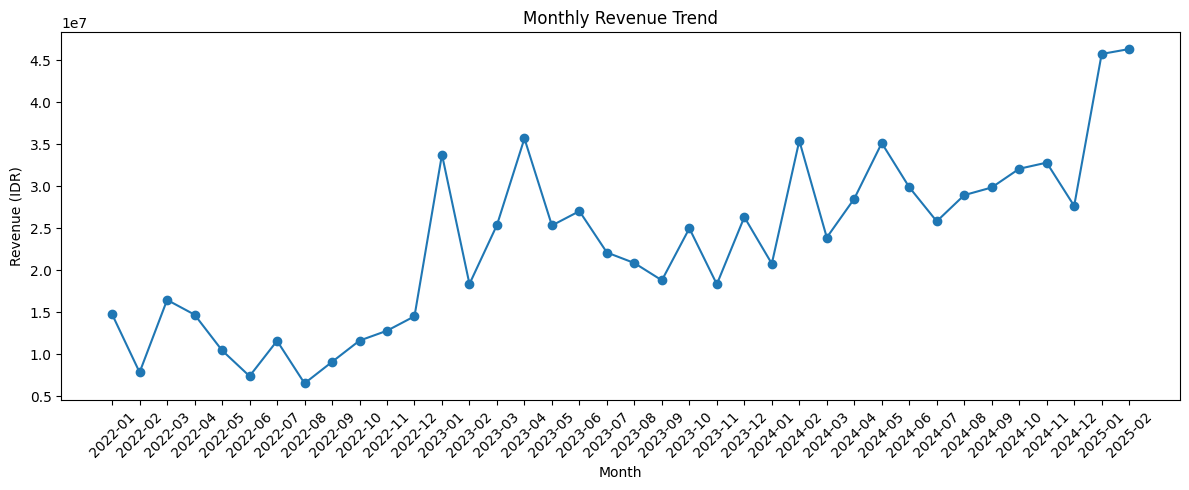

In [56]:
'''It groups all delivered orders by month, adds the revenue for each month, sorts the months in order, and shows
the result as a line chart to see whether revenue is increasing or decreasing over time.'''
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["year_month"],
    monthly_revenue["total_amount_idr"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (IDR)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
'''
Business question:Is the business growing, declining?
“This line chart shows how delivered revenue changes month by month. If the line goes up, revenue increased;
 if it goes down, revenue decreased; and if it moves up and down frequently, revenue fluctuated.”'''

In [59]:
'''It groups the orders by month and counts how many unique orders happened in each month.'''
monthly_orders = (
    orders
    .groupby("year_month")["order_id"]
    .nunique()
    .reset_index(name="total_orders")
)
print(monthly_orders)

   year_month  total_orders
0     2022-01            48
1     2022-02            29
2     2022-03            45
3     2022-04            38
4     2022-05            39
5     2022-06            38
6     2022-07            38
7     2022-08            35
8     2022-09            34
9     2022-10            42
10    2022-11            43
11    2022-12            40
12    2023-01            87
13    2023-02            69
14    2023-03           100
15    2023-04            90
16    2023-05           101
17    2023-06            96
18    2023-07            78
19    2023-08            90
20    2023-09            78
21    2023-10            80
22    2023-11            82
23    2023-12            92
24    2024-01           102
25    2024-02           119
26    2024-03            80
27    2024-04           108
28    2024-05           114
29    2024-06            93
30    2024-07            91
31    2024-08            93
32    2024-09           100
33    2024-10           102
34    2024-11       

In [62]:
'''First code = calculate monthly orders
Second code = arrange months in correct order
just an extra safety step to make sure the month order is correct before plotting.'''
monthly_orders = (
    monthly_orders
    .sort_values("year_month")
)
monthly_orders

,year_month,total_orders
0,2022-01,48
1,2022-02,29
2,2022-03,45
3,2022-04,38
4,2022-05,39
5,2022-06,38
6,2022-07,38
7,2022-08,35
8,2022-09,34
9,2022-10,42


In [64]:
'''order_items tells you what products were sold and how many, while
products tells you the product name, category, sub-category, brand.
“Add product details to each sold item.
Product + category analysis requires a merge”'''
product_sales = order_items.merge(
    products[
        [
            "product_id",
            "name",
            "category",
            "sub_category",
            "brand"
        ]
    ],
    on="product_id",
    how="left"
)

In [66]:
'''“Keep only products from delivered orders.”'''
product_sales = product_sales[
    product_sales["order_id"].isin(delivered_ids)
]
product_sales

,item_id,order_id,product_id,quantity,unit_price_idr,subtotal_idr,calculated_subtotal,name,category,sub_category,brand
3,ITM000004,ORD000002,PRD086,1,329000,329000,329000,Celana Jogger SandangIndo,Pants,Bawahan Wanita,SandangIndo
4,ITM000005,ORD000002,PRD258,1,129000,129000,129000,Kacamata Hitam Kanvas Lokal,Aksesoris,Aksesoris,Kanvas Lokal
5,ITM000006,ORD000002,PRD256,1,49000,49000,49000,Dress Maxi Polos Kanvas Lokal,Dress,Atasan Wanita,Kanvas Lokal
6,ITM000007,ORD000003,PRD076,1,199000,199000,199000,Syal Rajut Ratu Mode,Accessories,Aksesoris,Ratu Mode
10,ITM000011,ORD000007,PRD013,1,149000,149000,149000,Celana Cargo NusaBrand,Celana,Bawahan Pria,NusaBrand
...,...,...,...,...,...,...,...,...,...,...,...
4978,ITM004979,ORD002995,PRD259,1,599000,599000,599000,Dress Midi Floral NusaBrand,Dress,Atasan Wanita,NusaBrand
4979,ITM004980,ORD002995,PRD240,1,69000,69000,69000,Kemeja Linen Kanvas Lokal,Shirt,Atasan Pria,Kanvas Lokal
4980,ITM004981,ORD002996,PRD299,1,399000,399000,399000,T-Shirt Graphic BajuKita,Kaos,Atasan Pria,BajuKita
4981,ITM004982,ORD002996,PRD154,1,119000,119000,119000,Kemeja Oxford Cendana Co,Shirt,Atasan Wanita,Cendana Co


In [68]:
'''Now for category revenue:
“Group products by category and add their sales amount to find which category generated the most revenue.”
“Which category made the highest sales revenue?”'''
category_revenue = (
    product_sales
    .groupby("category")["subtotal_idr"]
    .sum()
    .sort_values(ascending=False)
)
category_revenue

,subtotal_idr
category,
Dress,154307000
Kaos,98623000
Kemeja,89857000
Jacket,83842000
Accessories,80688000
Pants,78969000
Jaket,72558000
Celana,70300000
Aksesoris,68376000


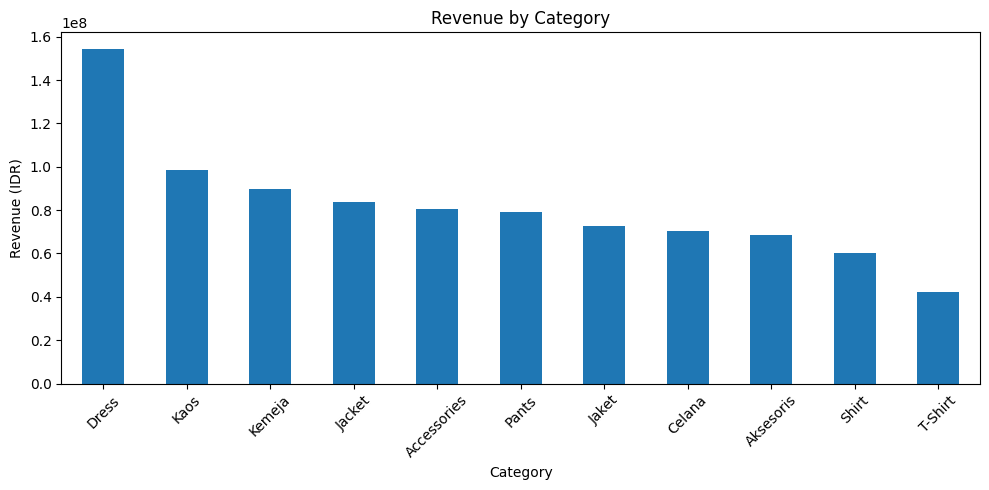

In [69]:
'''Which category generates the most product revenue?'''
category_revenue.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue (IDR)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [70]:
'''“This bar chart compares revenue across different product categories. The taller the bar, the more revenue
that category generated, so it helps identify the highest- and lowest-performing categories.”'''

'“This bar chart compares revenue across different product categories. The taller the bar, the more revenue \nthat category generated, so it helps identify the highest- and lowest-performing categories.”'

In [71]:
#Units Sold by Category
category_units = (
    product_sales
    .groupby("category")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

category_units

,quantity
category,
Dress,613
Kaos,467
Jacket,378
Kemeja,353
Aksesoris,344
Pants,341
Jaket,332
Accessories,312
Celana,270


In [72]:
'''Top 10 Products by Revenue'''
top_products_revenue = (
    product_sales
    .groupby("name")["subtotal_idr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_revenue

,subtotal_idr
name,
Dress Mini Casual SandangIndo,15467000
Kemeja Oxford NusaBrand,14059000
Celana Jeans Slim Riang Apparel,13906000
T-Shirt Graphic SandangIndo,13694000
T-Shirt Graphic BajuKita,12964000
Celana Jogger SandangIndo,11963000
Dompet Kulit Pesona Indo,11789000
Dress Wrap Senja Wear,11787000
Shirt Slim Fit Tropika Style,11599000


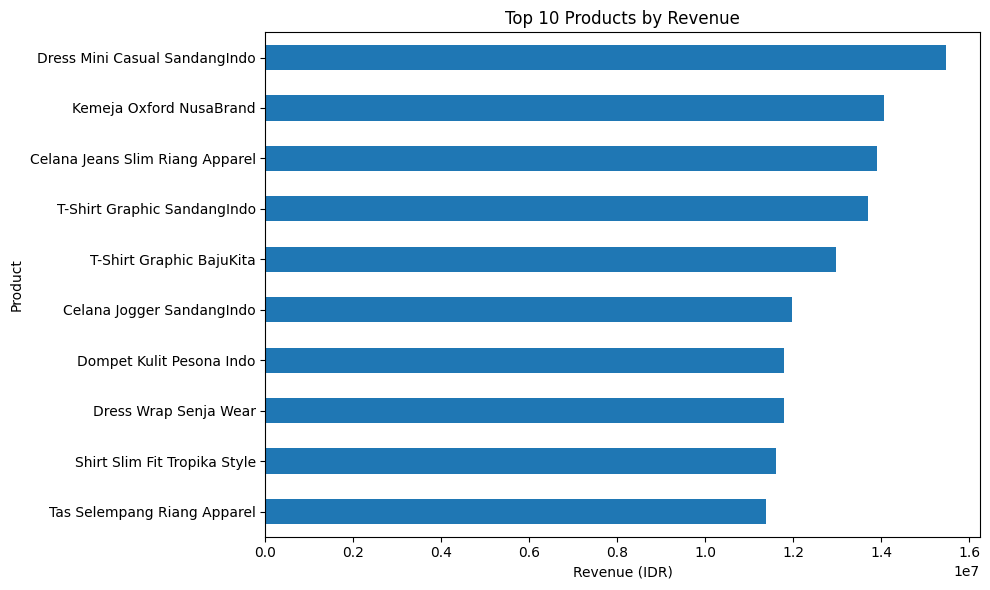

In [73]:
'''Why horizontal bar chart?
Because product names can be long.'''
top_products_revenue.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (IDR)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [ ]:
'''“This horizontal bar chart shows the top 10 products by revenue. Longer bars mean the product
generated more revenue, so it helps identify the highest-performing products.”'''

In [74]:
'''Top 10 Products by Quantity'''
top_products_quantity = (
    product_sales
    .groupby("name")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_quantity

,quantity
name,
Jacket Denim Ratu Mode,68
Jaket Hoodie Kanvas Lokal,55
Topi Baseball Cendana Co,54
Topi Baseball SandangIndo,53
Celana Jeans Slim Senja Wear,46
Jacket Coach NusaBrand,46
T-Shirt Graphic SandangIndo,46
Kaos Oversize BajuKita,44
Dress Wrap Senja Wear,43


In [75]:
'''Province = State/region large
Province = State'''
province_revenue = (
    delivered_orders
    .groupby("shipping_province")[
        "total_amount_idr"
    ]
    .sum()
    .sort_values(ascending=False)
)

province_revenue

,total_amount_idr
shipping_province,
Jawa Barat,169057544
Jawa Timur,88721580
Sumatera Utara,53925982
Sulawesi Utara,53893220
Jawa Tengah,51132128
Sulawesi Selatan,49617085
Kalimantan Barat,49099772
Banten,45322083
Kalimantan Timur,45219105


In [76]:
province_revenue.head(10)

,total_amount_idr
shipping_province,
Jawa Barat,169057544
Jawa Timur,88721580
Sumatera Utara,53925982
Sulawesi Utara,53893220
Jawa Tengah,51132128
Sulawesi Selatan,49617085
Kalimantan Barat,49099772
Banten,45322083
Kalimantan Timur,45219105


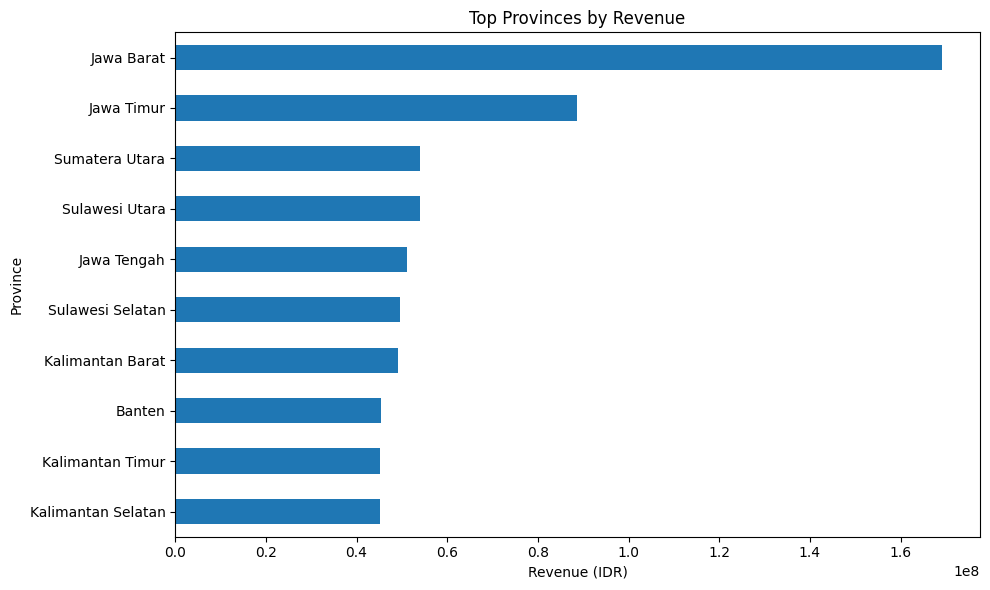

In [77]:
province_revenue.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top Provinces by Revenue")
plt.xlabel("Revenue (IDR)")
plt.ylabel("Province")

plt.tight_layout()
plt.show()

In [ ]:
'''“This horizontal bar chart shows the top 10 provinces by delivered revenue. The longer the bar, the more revenue that province generated.”'''


In [78]:
'''Top Cities by Orders'''
city_orders = (
    orders
    .groupby("shipping_city")[
        "order_id"
    ]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

city_orders

,order_id
shipping_city,
Medan,188
Manado,180
Depok,177
Bekasi,172
Pontianak,169
Malang,164
Semarang,163
Makassar,158
Balikpapan,152


In [79]:
'''Payment Method Analysis'''
payment_orders = (
    orders["payment_method"]
    .value_counts()
)

payment_orders

,count
payment_method,
Transfer Bank,907
GoPay,754
OVO,588
Kartu Kredit,445
QRIS,306


In [80]:
'''percentage
Which payment method do customers prefer?'''
payment_percentage = (
    orders["payment_method"]
    .value_counts(normalize=True)
    * 100
)

payment_percentage.round(2)

,proportion
payment_method,
Transfer Bank,30.23
GoPay,25.13
OVO,19.60
Kartu Kredit,14.83
QRIS,10.20


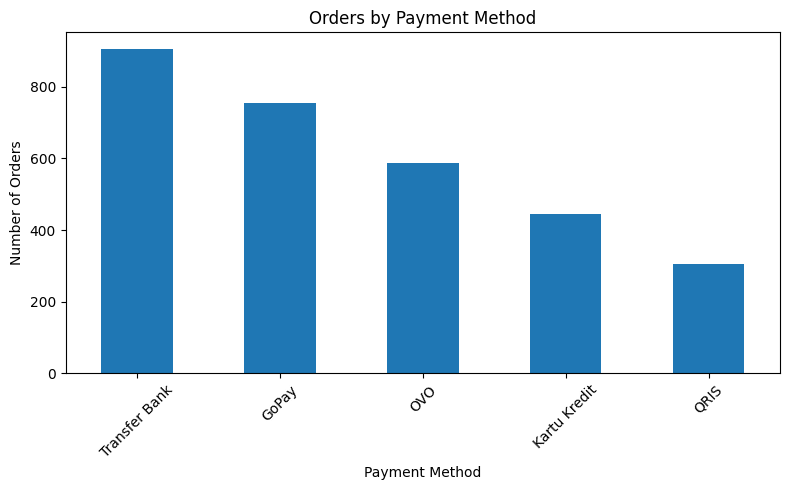

In [81]:
payment_orders.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
'''“This bar chart shows how many orders were placed using each payment method. The taller
 the bar, the more frequently that payment method was used.”'''

In [82]:
'''Order Status Distribution'''
status_counts = (
    orders["order_status"]
    .value_counts()
)

status_counts

,count
order_status,
delivered,1776
shipped,445
cancelled,328
processing,300
returned,151


In [83]:
status_percentage = (
    orders["order_status"]
    .value_counts(normalize=True)
    * 100
)

status_percentage.round(2)

,proportion
order_status,
delivered,59.20
shipped,14.83
cancelled,10.93
processing,10.00
returned,5.03


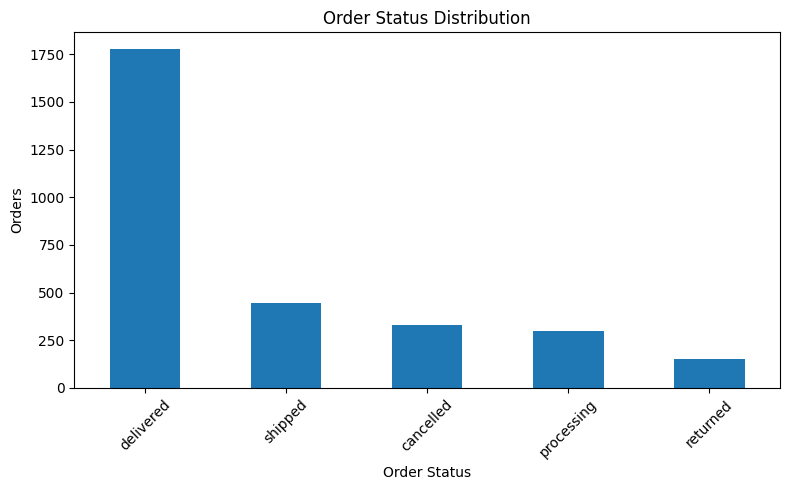

In [84]:
status_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
'''“This bar chart shows how many orders belong to each order status, such as delivered, cancelled, returned, shipped, or processing.
The taller the bar, the more orders there are in that status.”'''

In [85]:
'''Courier overview'''
courier_orders = (
    orders["courier"]
    .value_counts()
)

courier_orders

,count
courier,
J&T,896
JNE,845
SiCepat,791
Anteraja,307
Pos Indonesia,161


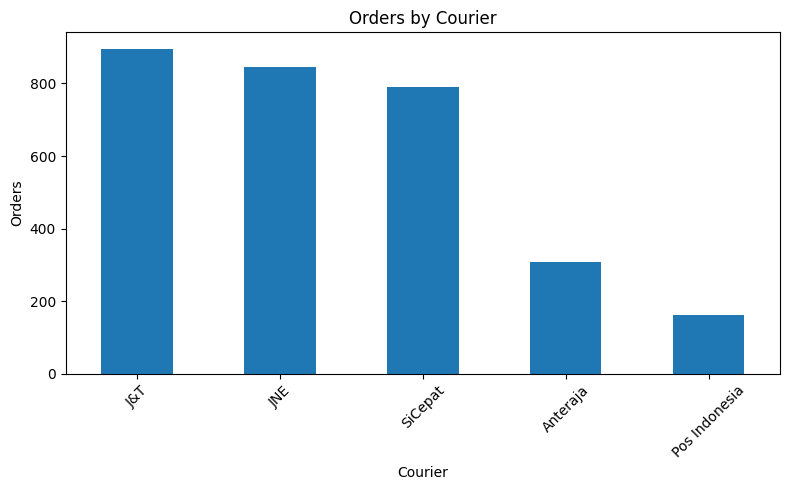

In [86]:
courier_orders.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Orders by Courier")
plt.xlabel("Courier")
plt.ylabel("Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
'''“This bar chart shows how many orders were handled by each courier. The taller the bar, the more orders that courier handled.”'''

In [87]:
'''Discount Usage'''
orders["used_discount"].value_counts()

,count
used_discount,
0,1786
1,1214


In [88]:
orders["used_discount"].value_counts(
    normalize=True
) * 100

,proportion
used_discount,
0,59.533333
1,40.466667


In [91]:
'''You can label it more clearly:'''
orders["discount_status"] = np.where(
    orders["used_discount"] == 1,
    "Discount Used",
    "No Discount"
)
orders["discount_status"].value_counts()

,count
discount_status,
No Discount,1786
Discount Used,1214


In [93]:
'''Orders with vs without discounts
qsn: Do discounted orders have higher average order values?'''
discount_comparison = (
    orders
    .groupby("discount_status")[
        "total_amount_idr"
    ]
    .agg(
        total_orders="count",
        average_order_value="mean",
        total_order_value="sum"
    )
)

discount_comparison

,total_orders,average_order_value,total_order_value
discount_status,,,
Discount Used,1214,482785.787479,586101946
No Discount,1786,508623.740202,908402000


In [95]:
'''Average rating by category'''
#merge
review_analysis = reviews.merge(
    products[
        [
            "product_id",
            "name",
            "category"
        ]
    ],
    on="product_id",
    how="left"
)

In [97]:
#Which categories receive the strongest customer ratings?
category_rating = (
    review_analysis
    .groupby("category")["rating"]
    .mean()
    .sort_values(ascending=False)
)

category_rating.round(2)

,rating
category,
Jaket,4.13
Dress,4.10
Aksesoris,4.08
Accessories,4.07
Pants,4.02
Celana,3.98
Kaos,3.98
Jacket,3.97
Kemeja,3.95


In [98]:
'''Rating Distribution'''
rating_distribution = (
    reviews["rating"]
    .value_counts()
    .sort_index()
)

rating_distribution

,count
rating,
1,66
2,104
3,234
4,430
5,666


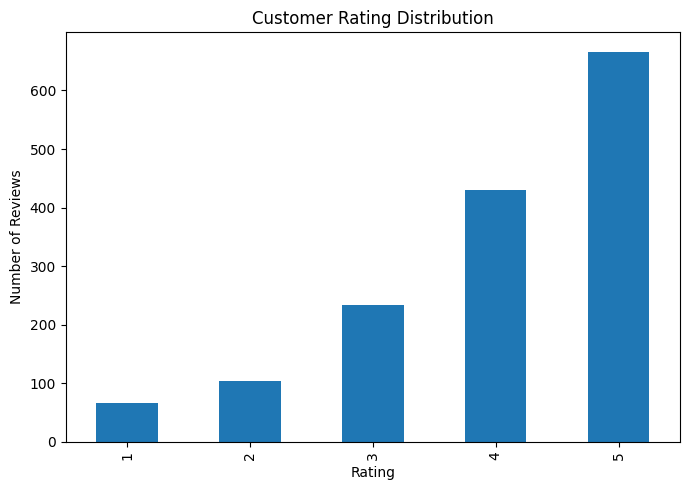

In [99]:
rating_distribution.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

In [ ]:
'''“This bar chart shows how customer reviews are distributed across ratings from 1 to 5. The
taller the bar, the more customers gave that rating.”'''

In [100]:
'''Create a clean Day 2 KPI table'''
summary = {
    "Total Revenue": total_revenue,
    "Total Orders": total_orders,
    "Delivered Orders": delivered_order_count,
    "Total Customers": total_customers,
    "Average Order Value": average_order_value,
    "Total Units Sold": total_units_sold,
    "Avg Items per Order": avg_items_per_order,
    "Total Discount": total_discount,
    "Cancellation Rate (%)": cancellation_rate,
    "Return Rate (%)": return_rate,
    "Average Rating": average_rating
}

for key, value in summary.items():
    print(f"{key}: {value}")

Total Revenue: 877752049
Total Orders: 3000
Delivered Orders: 1776
Total Customers: 787
Average Order Value: 494229.7573198198
Total Units Sold: 3783
Avg Items per Order: 2.1300675675675675
Total Discount: 37276054.0
Cancellation Rate (%): 10.933333333333334
Return Rate (%): 5.033333333333333
Average Rating: 4.017333333333333


In [ ]:
'''### KPI Summary

- Total Revenue shows the revenue generated from delivered orders.
- Total Orders shows how many unique orders were placed.
- Delivered Orders shows how many orders were successfully completed.
- Total Customers shows the number of unique customers.
- Average Order Value shows the average revenue generated per delivered order.
- Total Units Sold shows the total quantity of products sold.
- Average Items per Order shows how many items customers buy in one order on average.
- Total Discount shows the overall discount given to customers.
- Cancellation Rate shows the percentage of orders that were cancelled.
- Return Rate shows the percentage of orders that were returned.
- Average Rating shows the overall customer satisfaction level.'''

In [ ]:
'''### Key Takeaway
These KPIs give a quick overall view of the business performance, customer activity, order success,
 sales volume, discounts, cancellations, returns, and customer satisfaction.'''